## 1. Setup

In [ ]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

# Walk up from the notebook until we hit the directory that contains
# sgp_tta.py. Lets the notebook be launched from either the repo root
# or notebook/ without breaking imports and relative paths.
_here = Path.cwd().resolve()
for _p in (_here, *_here.parents):
    if (_p / 'sgp_tta.py').exists():
        REPO_ROOT = _p
        break
else:
    raise RuntimeError('Could not locate sgp_tta.py by walking up from CWD.')
sys.path.insert(0, str(REPO_ROOT))

from sgp_tta import SGPTTA

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device   :', device)
print('Repo root:', REPO_ROOT)


## 2. Config

In [ ]:
CHECKPOINT_PATH = REPO_ROOT / 'model' / 'DRIVE_unet.pth'
SAMPLE_DIR      = REPO_ROOT / 'sample'

MODEL_NAME   = 'unet'
ENCODER_NAME = 'resnet50'
IN_CHANNELS  = 3
NUM_CLASSES  = 1
IMAGE_SIZE   = 512

INVERT_DEFAULT = True   # Per-image override below forces invert=False for stare_*.


## 3. Dataset

In [ ]:
def should_invert(path, invert_default):
    """STARE samples share the DRIVE-source polarity (dark vessels on
    bright fundus background) and must NOT be inverted. OCTA / road
    targets have the opposite polarity and benefit from the 1 - x
    inversion."""
    if Path(path).stem.lower().startswith('stare'):
        return False
    return invert_default


class InferenceDataset(Dataset):
    def __init__(self, image_paths, image_size, invert_default=True):
        self.image_paths = list(image_paths)
        self.invert_default = invert_default
        self.transform = A.Compose([
            A.Resize(height=image_size, width=image_size),
            A.Normalize(mean=0.0, std=1.0, max_pixel_value=255.0),
            ToTensorV2(),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image_rgb = np.array(Image.open(path).convert('RGB'))
        image_tensor = self.transform(image=image_rgb)['image']
        if should_invert(path, self.invert_default):
            image_tensor = 1.0 - image_tensor
        return {
            'image':     image_tensor,
            'image_rgb': image_rgb,
            'path':      str(path),
        }


image_paths = sorted(SAMPLE_DIR.glob('*.png'))
dataset = InferenceDataset(image_paths, IMAGE_SIZE, invert_default=INVERT_DEFAULT)
loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)
print(f'{len(dataset)} sample images | invert_default={INVERT_DEFAULT}')
for p in image_paths:
    print(f'  {Path(p).name:<20s} invert={should_invert(p, INVERT_DEFAULT)}')


## 4. Load the source model

In [10]:
def fresh_model():
    model = smp.Unet(
        encoder_name=ENCODER_NAME,
        encoder_weights=None,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        activation=None,
    ).to(device)
    state = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    if isinstance(state, dict) and 'model_state_dict' in state:
        state = state['model_state_dict']
    model.load_state_dict(state, strict=True)
    return model


print(f'checkpoint: {CHECKPOINT_PATH}')
print(f'arch      : smp.{MODEL_NAME} | encoder={ENCODER_NAME} | in={IN_CHANNELS} | classes={NUM_CLASSES}')


checkpoint: model\DRIVE_unet.pth
arch      : smp.unet | encoder=resnet50 | in=3 | classes=1


## 5. Source-only inference


In [11]:
def run_source(model, loader):
    preds = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            img = batch['image'].to(device)
            logits = model(img)
            prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
            preds.append(prob)
    return preds


source_probs = run_source(fresh_model(), loader)
print(f'source predictions: {len(source_probs)}')


source predictions: 3


## 6. SGP-TTA adaptation

In [12]:
def run_sgptta(loader):
    tta = SGPTTA(
        model=fresh_model(),
        temperature=5.0,
        lr=1e-3,
        num_steps=1,
        entropy_weight=1.0,
        skeleton_weight=1.0,
        dilate_radius=2,
    )
    preds = []
    for batch in loader:
        img = batch['image'].to(device)
        logits = tta(img)
        prob = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()
        preds.append(prob)
    print('sgp-tta stats:', tta.get_stats())
    return preds


sgptta_probs = run_sgptta(loader)
print(f'sgp-tta predictions: {len(sgptta_probs)}')


sgp-tta stats: {'adaptation_count': 3, 'num_bn_params': 126, 'num_steps': 1}
sgp-tta predictions: 3


## 7. Compare

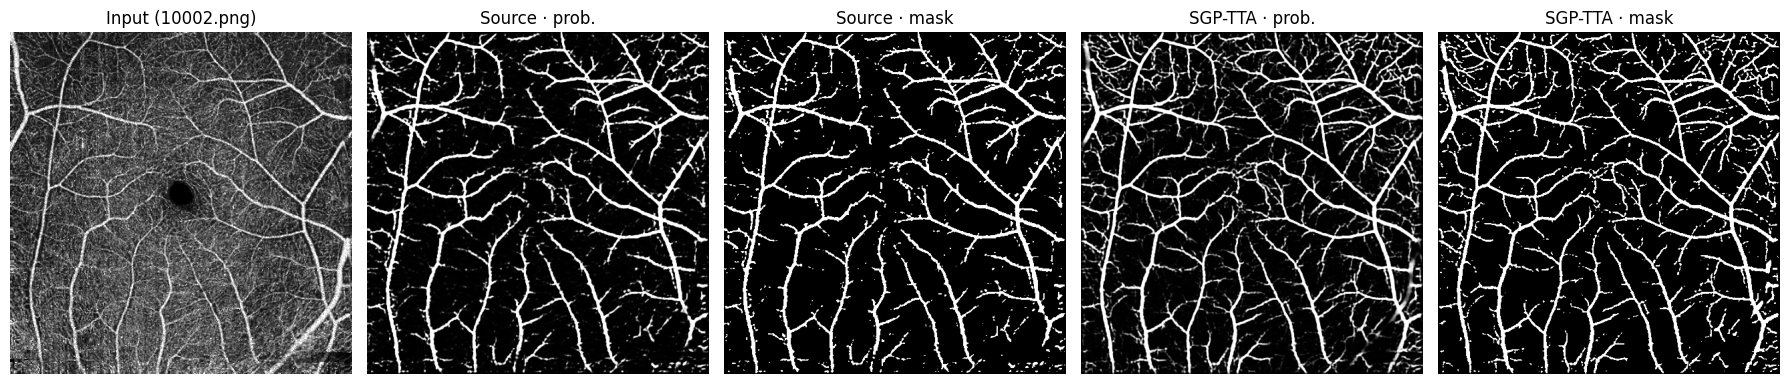

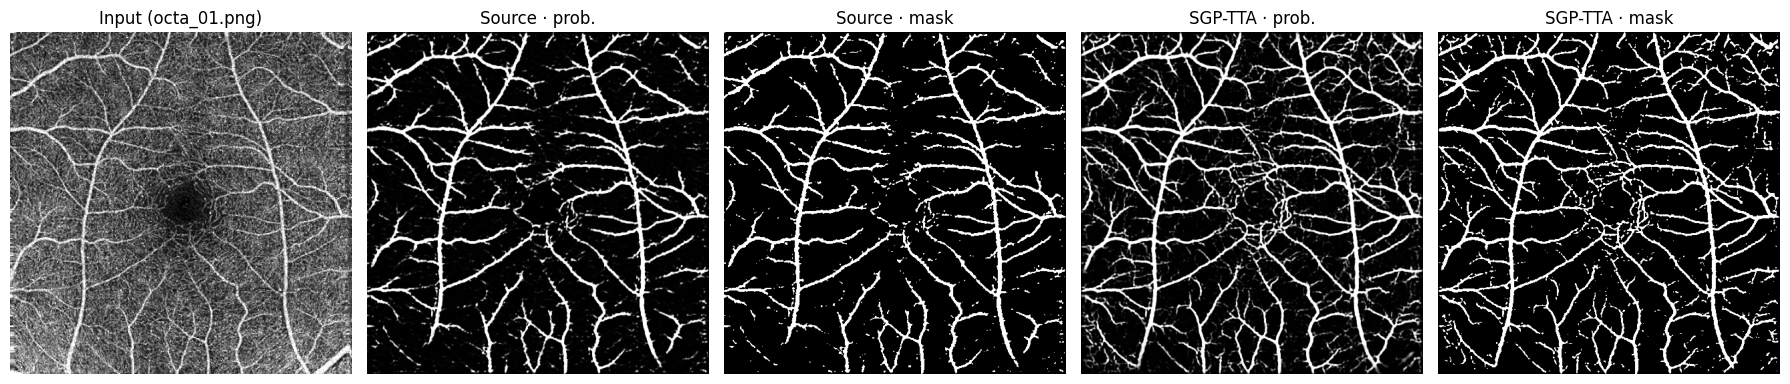

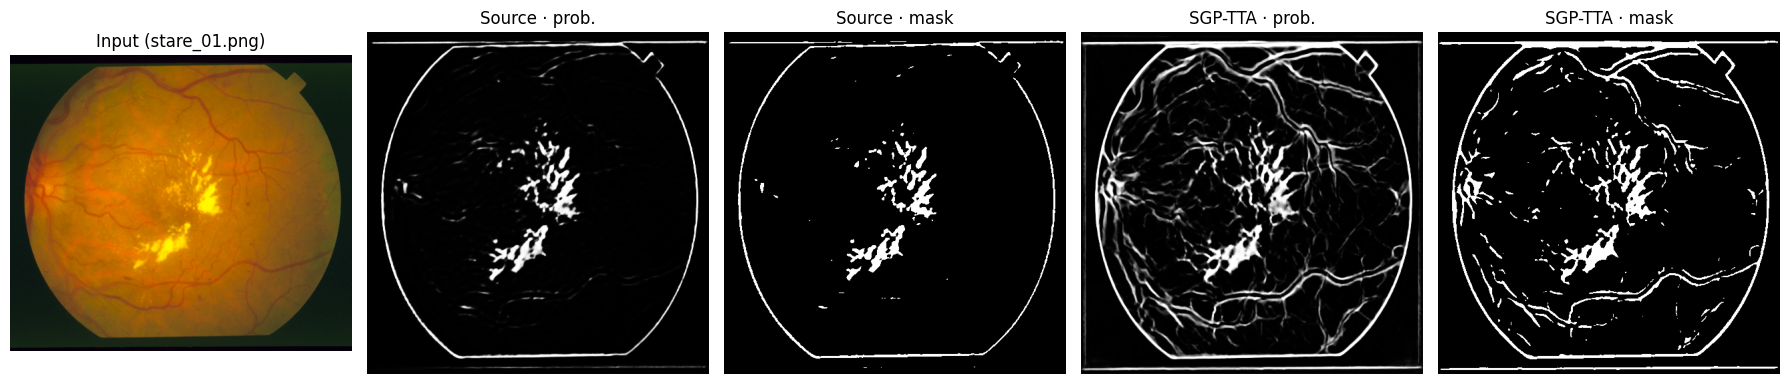

In [13]:
def show_row(image_rgb, src_prob, adapted_prob, threshold=0.5, title=None):
    src_mask     = (src_prob     > threshold).astype(np.uint8)
    adapted_mask = (adapted_prob > threshold).astype(np.uint8)

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    axes[0].imshow(image_rgb)
    axes[0].set_title(title or 'Input')

    axes[1].imshow(src_prob, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Source · prob.')

    axes[2].imshow(src_mask, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title('Source · mask')

    axes[3].imshow(adapted_prob, cmap='gray', vmin=0, vmax=1)
    axes[3].set_title('SGP-TTA · prob.')

    axes[4].imshow(adapted_mask, cmap='gray', vmin=0, vmax=1)
    axes[4].set_title('SGP-TTA · mask')

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


for i, batch in enumerate(dataset):
    show_row(
        batch['image_rgb'],
        source_probs[i],
        sgptta_probs[i],
        title=f'Input ({Path(batch["path"]).name})',
    )
